# G1 — Modelos de goles: Poisson y Dixon-Coles vs baseline G0

**EXP-001** del protocolo (`research/PROTOCOLO_INVESTIGACION.md`). Pregunta:
¿un modelo de fuerzas ataque/defensa sobre goles supera a la logística de
Δppg (G0) y a la tasa base, bajo **walk-forward semanal** en 2026?

- Hiperparámetros (decaimiento temporal, shrinkage, ρ) elegidos **solo con 2025**
  (ver `config.json`); 2026 es evaluación pura.
- Métrica primaria: **RPS**; log-loss/Brier/ECE secundarias; bootstrap pareado.
- Corrida pesada: `research/experiments/EXP-001-model-ladder/run.py` →
  este notebook analiza `walkforward_2026.csv` (no reentrena).

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

here = Path.cwd()
for p in [here, *here.parents]:
    if (p / 'research').is_dir():
        ROOT = p; sys.path.insert(0, str(p)); break
from research.peak_models.evaluate import (ORDER, PCOLS, compare,
                                           rps_per_match, ece)

EXP = ROOT / 'research' / 'experiments' / 'EXP-001-model-ladder'
cfg = json.loads((EXP / 'config.json').read_text())
res = pd.read_csv(EXP / 'walkforward_2026.csv', parse_dates=['date'])
print('config tuning →', cfg['tuning']['best'])
print('partidos 2026 evaluados:', res.match_id.nunique(), '| modelos:', list(res.model.unique()))

config tuning → {'halflife_days': 120.0, 'ridge_sigma': 0.75, 'fit_rho': True}
partidos 2026 evaluados: 507 | modelos: ['b0_base_rate', 'g0_logistic_dppg', 'poisson_plain', 'dc_best']


## 1. Tabla de comparación (RPS = métrica primaria; menor es mejor)

In [2]:
table = compare(res, baseline='g0_logistic_dppg')
table.round(4)

,n,rps,log_loss,brier,ece_home,accuracy,d_rps_vs_base,d_rps_ci,p_better_rps,d_logloss_vs_base,p_better_logloss
model,,,,,,,,,,,
dc_best,507,0.2107,0.9918,0.5921,0.0693,0.5523,-0.0086,"(-0.0179, 0.001)",0.9628,-0.0306,0.9740
poisson_plain,507,0.2159,1.0075,0.6034,0.0743,0.5187,-0.0034,"(-0.0145, 0.0073)",0.7318,-0.0149,0.8102
g0_logistic_dppg,507,0.2193,1.0224,0.6123,0.0603,0.5227,NaN,NaN,NaN,NaN,NaN
b0_base_rate,507,0.2377,1.0675,0.6468,0.0885,0.4458,0.0184,"(0.0093, 0.0272)",0.0000,0.0451,0.0005


Lectura: `d_rps_vs_base` < 0 con IC que excluye 0 ⇒ mejora significativa sobre G0. `p_better_rps` ≈ probabilidad bootstrap de ser mejor que G0.

## 2. RPS por liga — ¿dónde aporta el modelo de goles?

league_code           M1     M1L      M2      NL      VL
model                                                   
b0_base_rate      0.1949  0.2218  0.2286  0.2332  0.2212
dc_best           0.2153  0.2271  0.2263  0.2308  0.2142
g0_logistic_dppg  0.2162  0.2176  0.2149  0.2384  0.2343
poisson_plain     0.2251  0.2150  0.2164  0.2154  0.2220


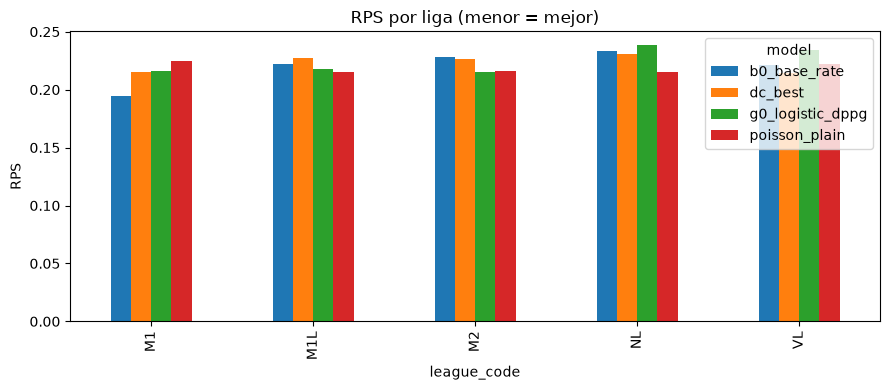

In [3]:
res['rps'] = np.concatenate([
    rps_per_match(g[PCOLS].to_numpy(), g['result'].to_numpy())
    for _, g in res.groupby('model', sort=False)])
by_lg = res.groupby(['model','league_code'])['rps'].mean().unstack().round(4)
print(by_lg.to_string())
by_lg.T.plot(kind='bar', figsize=(9,4))
plt.title('RPS por liga (menor = mejor)'); plt.ylabel('RPS')
plt.tight_layout(); plt.show()

## 3. Calibración de P(local) — el requisito para hablar de value

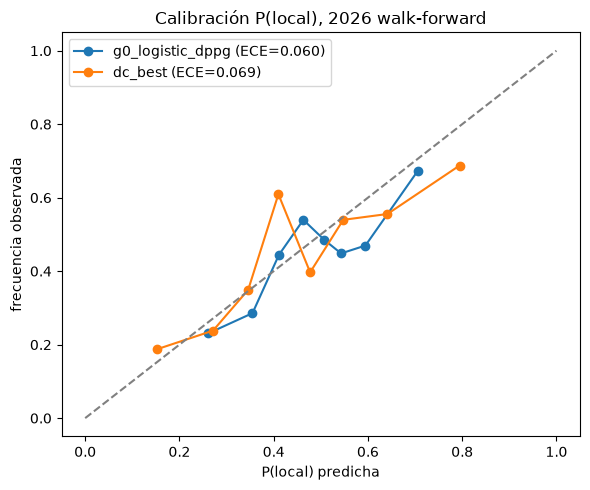

In [4]:
from sklearn.calibration import calibration_curve
plt.figure(figsize=(6,5))
for mdl in ['g0_logistic_dppg','dc_best']:
    g = res[res.model==mdl]
    frac, mean = calibration_curve((g.result=='H').astype(int), g.p_home,
                                   n_bins=8, strategy='quantile')
    plt.plot(mean, frac, 'o-', label=f"{mdl} (ECE={ece(g[PCOLS].to_numpy(), g.result.to_numpy()):.3f})")
plt.plot([0,1],[0,1],'--',c='gray'); plt.legend()
plt.xlabel('P(local) predicha'); plt.ylabel('frecuencia observada')
plt.title('Calibración P(local), 2026 walk-forward'); plt.tight_layout(); plt.show()

## 4. Sharpness y desacuerdos — proto-señales de value

In [5]:
wide = res.pivot_table(index='match_id', columns='model', values='p_home')
meta = res.drop_duplicates('match_id').set_index('match_id')
wide['disagree'] = (wide['dc_best'] - wide['g0_logistic_dppg']).abs()
top = wide.nlargest(10,'disagree').join(meta[['date','league_code','home_team','away_team','result']])
print('mayores desacuerdos dc_best vs G0 (candidatos a señal cuando haya cuotas):')
top[['date','league_code','home_team','away_team','g0_logistic_dppg','dc_best','result']].round(3)

mayores desacuerdos dc_best vs G0 (candidatos a señal cuando haya cuotas):


/var/folders/t0/sw_s1cgd2rb1zn5pvv4wq1040000gn/T/ipykernel_51794/3039958003.py:6: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  top[['date','league_code','home_team','away_team','g0_logistic_dppg','dc_best','result']].round(3)


,date,league_code,home_team,away_team,g0_logistic_dppg,dc_best,result
match_id,,,,,,,
4038185,2026-04-04,NL,Kuopion Palloseura,PK-35 Vantaa,0.210,0.732,H
4038178,2026-03-28,NL,Idrottsföreningen Kamraterna Vasa,Helsingin Jalkapalloklubi,0.535,0.023,A
4057762,2026-05-02,M2,Hämeenlinnan Jalkapalloseura,FC Honka,0.629,0.150,A
4057842,2026-04-19,M2,Vaasan Palloseura,Tornion Pallo-47,0.520,0.941,D
4036869,2026-04-18,VL,IFK Mariehamn Fotboll,Ilves,0.565,0.167,D
4057772,2026-05-17,M2,Ilves,Pallo-Iirot,0.285,0.670,H
4057848,2026-04-25,M2,FC Vaajakoski,Jalkapalloseura Hercules,0.123,0.499,A
4057751,2026-04-18,M2,FC Honka,Idrottsföreningen Kamraterna i Åbo,0.520,0.890,D
4057770,2026-05-16,M2,GrIFK - Fotboll,FC Honka,0.450,0.089,A


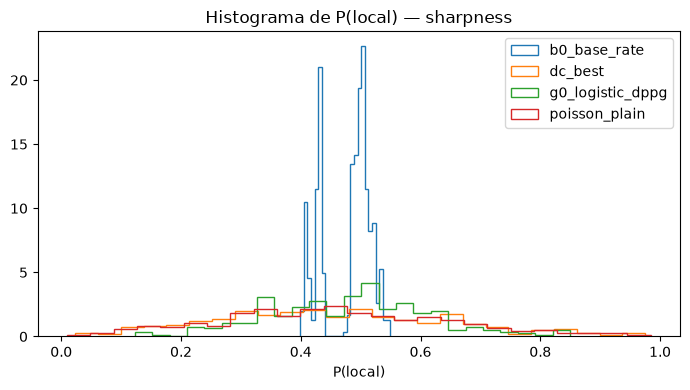

In [6]:
plt.figure(figsize=(7,4))
for mdl, g in res.groupby('model'):
    plt.hist(g.p_home, bins=25, histtype='step', label=mdl, density=True)
plt.legend(); plt.title('Histograma de P(local) — sharpness')
plt.xlabel('P(local)'); plt.tight_layout(); plt.show()

## 5. Conclusiones (completar tras leer §1-§4)

- Si `dc_best` gana a G0 con IC excluyendo 0 → **G2 pasado** para Finlandia;
  el siguiente escalón del protocolo es el jerárquico bayesiano multi-liga
  y sumar ligas (Noruega/Suecia/Islandia).
- Si la calibración (§3) es buena, el modelo ya produce probabilidades usables
  para **comparar contra cuotas** en cuanto la Fase 0 (archivado) acumule datos.
- Pendientes del protocolo: features de forma/momentum/SoS como capa logística
  sobre λs (stacking), O/U y BTTS (el modelo ya emite `p_over25`/`p_btts`),
  y CLV cuando existan cuotas archivadas.